In [1]:
from pyspoc import Calculator, Config

my_config_dict = {
    'ReducedStatistics': {
        'GPLVM_R2.py': {
            'GPLVM_r2': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPLVM_Beta.py': {
            'GPLVM_beta': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPLVM_DoF.py': {
            'GPLVM_dof': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPyTorch_BayesianGPLVM_R2.py': {
            'GPyTorch_BayesianGPLVM_R2': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPyTorch_BayesianGPLVM_Beta.py': {
            'GPyTorch_BayesianGPLVM_Beta': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        },
        'GPyTorch_BayesianGPLVM_Dim3.py': {
            'GPyTorch_BayesianGPLVM_Dim3': {
                'schemes': {
                    'scheme_1': {
                        'ARD_initial_dimension': 10,
                        'max_iters': 200
                    }
                }
            }
        }
    }
}

cfg = Config.from_dict("auto_cfg", my_config_dict)

Octave not available: No module named 'oct2py'
Jpype JVM not available: No module named 'jpype'
Registering configuration dictionary object.
Building internal configuration.
GPLVM_R2.py
    ✔ ReducedStatistic GPLVM_r2 scheme 'scheme_1' added successfully.
GPLVM_Beta.py
    ✔ ReducedStatistic GPLVM_beta scheme 'scheme_1' added successfully.
GPLVM_DoF.py
    ✔ ReducedStatistic GPLVM_dof scheme 'scheme_1' added successfully.
GPyTorch_BayesianGPLVM_R2.py
    ✔ ReducedStatistic GPyTorch_BayesianGPLVM_R2 scheme 'scheme_1' added successfully.
GPyTorch_BayesianGPLVM_Beta.py
    ✔ ReducedStatistic GPyTorch_BayesianGPLVM_Beta scheme 'scheme_1' added successfully.
GPyTorch_BayesianGPLVM_Dim3.py
    ✔ ReducedStatistic GPyTorch_BayesianGPLVM_Dim3 scheme 'scheme_1' added successfully.


In [2]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import cholesky, block_diag
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_swiss_roll, make_s_curve


# generate noise for each dataset
def add_noise(Y: np.ndarray, sigma: float, rng=None) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()
    return Y + sigma * rng.normal(size=Y.shape)



def run_all_and_store_results(datasets: dict, cfg):
    """
    datasets: dict[name -> np.ndarray of shape (1000,100)]
    cfg: py-spoc Config
    """
    all_results = {}
    names = list(datasets.keys())  

    for i, name in enumerate(names, 1):
        X = datasets[name]


        calc = Calculator(X)
        calc.compute(cfg)

        all_results[name] = calc.results
        print(f"[{i:02d}/{len(names)}] done: {name}")

    return all_results



# 1. Smooth manifold generator: Swiss Roll, S-Curve, Helicoid, Sphere, Intersecting Planes
class SyntheticDataGenerator:
    def __init__(self, n_samples=1000, n_features=100, seed=42):
        self.n = n_samples
        self.p = n_features
        self.rng = np.random.default_rng(seed)
        self.datasets = {}
        self.meta = {}

    def _project_to_high_dim(self, X_low):
        d = X_low.shape[1]
        Q, _ = np.linalg.qr(self.rng.normal(size=(self.p, d)))
        X_high = X_low @ Q.T
        return StandardScaler().fit_transform(X_high)

    def add_noise(self, X_clean, noise_level=0.1):
        return X_clean + self.rng.normal(size=X_clean.shape) * noise_level

    def generate_all(self, noise_level=0.1):
        # 1) Swiss Roll, intrinsic dim = 2
        X_low, _ = make_swiss_roll(n_samples=self.n, noise=0.0, random_state=123)
        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["Swiss Roll"] = X
        self.meta["Swiss Roll"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        # 2) S-Curve, intrinsic dim = 2
        X_low, _ = make_s_curve(n_samples=self.n, noise=0.0, random_state=456)
        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["S-Curve"] = X
        self.meta["S-Curve"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        # 3) Helicoid, intrinsic dim = 2
        m1 = int(np.sqrt(self.n))
        m2 = int(np.ceil(self.n / m1))
        t = np.linspace(0, 4 * np.pi, m1)
        r = np.linspace(0.6, 1.4, m2)
        T, R = np.meshgrid(t, r)
        T = T.ravel()[:self.n]
        R = R.ravel()[:self.n]

        x = R * np.cos(T)
        y = R * np.sin(T)
        z = 0.1 * T
        X_low = np.stack([x, y, z], axis=1)

        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["Helicoid"] = X
        self.meta["Helicoid"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        # 4) Sphere, intrinsic dim = 2
        u = self.rng.random(self.n)
        v = self.rng.random(self.n)
        theta = 2 * np.pi * u
        phi = np.arccos(2 * v - 1)
        x = np.sin(phi) * np.cos(theta)
        y = np.sin(phi) * np.sin(theta)
        z = np.cos(phi)
        X_low = np.stack([x, y, z], axis=1)

        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["Sphere"] = X
        self.meta["Sphere"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        # 5) Intersecting Planes, intrinsic dim = 2
        n1 = self.n // 2
        n2 = self.n - n1
        d1 = self.rng.normal(size=(n1, 2))
        X1 = np.hstack([d1, np.zeros((n1, 1))])
        d2 = self.rng.normal(size=(n2, 2))
        X2 = np.hstack([np.zeros((n2, 1)), d2])
        X_low = np.vstack([X1, X2])

        X = self.add_noise(self._project_to_high_dim(X_low), noise_level)
        self.datasets["Intersecting Planes"] = X
        self.meta["Intersecting Planes"] = {"family": "manifold", "true_dim": 2, "noise": noise_level}

        return self.datasets, self.meta



# 2. Gaussian process latent generator:latent_i
def latent_circle(n: int, rng: np.random.Generator) -> np.ndarray:
    theta = 2 * np.pi * rng.random(n)
    Z = np.column_stack([np.cos(theta), np.sin(theta)])
    return Z


def lmm_generate(
    Z: np.ndarray,
    p: int,
    sigma: float,
    rng: np.random.Generator,
    kernel: str = "rbf",
    alpha: float = 1.0,
    gamma: float = 1.0,
    eps: float = 1e-8,
) -> np.ndarray:
    n = Z.shape[0]

    if kernel == "rbf":
        sq = squareform(pdist(Z, metric="sqeuclidean"))
        K = alpha * np.exp(-0.5 * gamma * sq)
    elif kernel == "poly2":
        G = Z @ Z.T
        K = (G + 1.0) ** 2
    elif kernel == "random":
        A = rng.normal(size=(n, n))
        K = A @ A.T
    else:
        raise ValueError("kernel must be one of {'rbf','poly2','random'}")

    K = K + np.eye(n) * eps
    L = cholesky(K, lower=True)

    W = rng.normal(size=(n, p))
    X_signal = L @ W

    if sigma > 0:
        X_noise = sigma * rng.normal(size=(n, p))
        Y = X_signal + X_noise
    else:
        Y = X_signal

    return Y.astype(np.float64, copy=False)


def stretch_latent_circle(Z: np.ndarray, sx: float = 1.0, sy: float = 1.0) -> np.ndarray:
    if Z.shape[1] != 2:
        raise ValueError("stretch_latent_circle expects Z with shape (n, 2).")

    S = np.array([[sx, 0.0], [0.0, sy]])
    return Z @ S.T


def generate_latent_group(
    n_samples: int = 1000,
    n_features: int = 100,
    sigma: float = 0.1,
    kernel: str = "rbf",
    alpha: float = 1.0,
    gamma: float = 1.0,
    latent_seed: int = 42,
    obs_seed: int = 999,
):
    rng_latent = np.random.default_rng(latent_seed)
    Z_base = latent_circle(n_samples, rng_latent)

    stretch_specs = [
        (1.06, 0.91),
        (1.05, 0.95),
        (1.10, 0.90),
        (1.08, 1.00),
        (1.00, 0.92),
    ]

    datasets = {}
    meta = {}

    for i, (sx, sy) in enumerate(stretch_specs, start=1):
        Z_use = stretch_latent_circle(Z_base, sx=sx, sy=sy)
        rng_obs = np.random.default_rng(obs_seed)

        Y = lmm_generate(
            Z=Z_use,
            p=n_features,
            sigma=sigma,
            rng=rng_obs,
            kernel=kernel,
            alpha=alpha,
            gamma=gamma,
        )

        name = f"latent_{i}"
        datasets[name] = Y
        meta[name] = {
            "family": "lmm_latent",
            "sigma": sigma,
            "kernel": kernel,
            "stretch": (sx, sy),
        }

    return datasets, meta



# 3. sparse generator: sparse_i
def sparse_factor_model(
    n: int,
    p: int,
    q_true: int,
    sigma: float,
    sparsity: float = 0.9,
    rng=None
) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()

    Z = rng.normal(size=(n, q_true))
    A = rng.normal(size=(p, q_true)) / np.sqrt(q_true)

    mask = rng.random(size=A.shape) > sparsity
    A = A * mask

    for j in range(q_true):
        if np.all(A[:, j] == 0):
            idx = rng.integers(0, p)
            A[idx, j] = rng.normal()

    Y = Z @ A.T
    Y = add_noise(Y, sigma, rng)
    return Y.astype(np.float64, copy=False)


def generate_sparse_group(n=1000, p=100, seed=42):
    rng = np.random.default_rng(seed)
    datasets = {}
    meta = {}

    sparsity_list = [0.82, 0.84, 0.86, 0.88, 0.90]

    for i, s in enumerate(sparsity_list, start=1):
        Y = sparse_factor_model(
            n=n,
            p=p,
            q_true=1,
            sigma=0.01,
            sparsity=s,
            rng=rng
        )
        name = f"sparse_{i}"
        datasets[name] = Y
        meta[name] = {
            "family": "sparse_factor",
            "true_dim": 1,
            "noise": 0.01,
            "sparsity": s,
        }

    return datasets, meta



# 4. Linear low-rank generator: linear_i
def linear_low_rank(n: int, p: int, q_true: int, sigma: float, rng=None) -> np.ndarray:
    if rng is None:
        rng = np.random.default_rng()
    Z = rng.normal(size=(n, q_true))
    A = rng.normal(size=(p, q_true)) / np.sqrt(q_true)
    Y = Z @ A.T
    Y = add_noise(Y, sigma, rng)
    return Y.astype(np.float64, copy=False)


def generate_linear_group(n=1000, p=100, seed=52):
    datasets = {}
    meta = {}

    q_true = 1
    sigma = 0.01

    for i in range(1, 6):
        rng = np.random.default_rng(seed + i)

        Y = linear_low_rank(
            n=n,
            p=p,
            q_true=q_true,
            sigma=sigma,
            rng=rng
        )

        name = f"linear_{i}"
        datasets[name] = Y
        meta[name] = {
            "family": "linear_low_rank",
            "true_dim": q_true,
            "noise": sigma,
            "seed": seed + i,
        }

    return datasets, meta



# 5. Block covariance generator
def make_block_covariance_matrix(
    p: int,
    n_blocks: int,
    rho_within: float = 0.75,
    rho_between: float = 0.00
) -> np.ndarray:
    if not (0.0 <= rho_between <= rho_within < 1.0):
        raise ValueError("Need 0 <= rho_between <= rho_within < 1")

    block_sizes = np.full(n_blocks, p // n_blocks, dtype=int)
    block_sizes[: p % n_blocks] += 1

    blocks = []
    for b in block_sizes:
        B = (1.0 - rho_within) * np.eye(b) + rho_within * np.ones((b, b))
        blocks.append(B)

    Sigma = block_diag(*blocks)

    if rho_between > 0:
        Sigma = Sigma + rho_between * (np.ones((p, p)) - np.eye(p))
        np.fill_diagonal(Sigma, 1.0)

    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = Sigma + 1e-8 * np.eye(p)
    return Sigma


def block_covariance_dataset(
    n: int,
    p: int,
    n_blocks: int,
    sigma: float = 0.30,
    rho_within: float = 0.75,
    rho_between: float = 0.00,
    rng=None
):
    if rng is None:
        rng = np.random.default_rng()

    Sigma = make_block_covariance_matrix(
        p=p,
        n_blocks=n_blocks,
        rho_within=rho_within,
        rho_between=rho_between
    )

    L = np.linalg.cholesky(Sigma)
    X = rng.normal(size=(n, p)) @ L.T

    if sigma > 0:
        X = X + sigma * rng.normal(size=(n, p))

    return X.astype(np.float64, copy=False), Sigma


def generate_block_group(n=1000, p=100, seed=123):
    rng = np.random.default_rng(seed)
    datasets = {}
    sigmas = {}
    meta = {}

    for i, k in enumerate([2, 3, 4, 5, 6], start=1):
        Y, Sigma = block_covariance_dataset(
            n=n,
            p=p,
            n_blocks=k,
            sigma=0.30,
            rho_within=0.75,
            rho_between=0.02,
            rng=rng
        )
        name = f"block_{i}"
        datasets[name] = Y
        sigmas[name] = Sigma
        meta[name] = {
            "family": "block_covariance",
            "n_blocks": k,
            "rho_within": 0.75,
            "rho_between": 0.02,
            "noise": 0.30,
            "n": n,
            "p": p,
            "manifold": False,
        }

    return datasets, sigmas, meta



# 6. Gaussian random noise generator: noise_i
def iid_gaussian(n: int, p: int, sigma: float, rng: np.random.Generator) -> np.ndarray:
    Y = rng.normal(size=(n, p))
    Y = add_noise(Y, sigma, rng)
    return Y.astype(np.float64, copy=False)


def generate_noise_group(n=1000, p=100, seed=777):
    rng = np.random.default_rng(seed)
    datasets = {}
    meta = {}

    sigma_list = [0.05, 0.10, 0.15, 0.20, 0.25]

    for i, s in enumerate(sigma_list, start=1):
        Y = iid_gaussian(n=n, p=p, sigma=s, rng=rng)
        name = f"noise_{i}"
        datasets[name] = Y
        meta[name] = {
            "family": "iid_gaussian_noise",
            "noise": s,
            "n": n,
            "p": p,
        }

    return datasets, meta



# 5 smooth manifold datasets
smooth_gen = SyntheticDataGenerator(n_samples=1000, n_features=100, seed=42)
smooth_datasets_5, smooth_meta_5 = smooth_gen.generate_all(noise_level=0.1)

# 5 gaussian process latent datasets
latent_datasets_5, latent_meta_5 = generate_latent_group(
    n_samples=1000,
    n_features=100,
    sigma=0.1,
    kernel="rbf",
    alpha=1.0,
    gamma=1.0,
    latent_seed=42,
    obs_seed=999,
)

# 5 sparse datasets
sparse_datasets_5, sparse_meta_5 = generate_sparse_group(n=1000, p=100, seed=42)

# 5 linear low-rank datasets
linear_datasets_5, linear_meta_5 = generate_linear_group(n=1000, p=100, seed=52)

# 5 block covariance datasets
block_datasets_5, block_sigmas_5, block_meta_5 = generate_block_group(n=1000, p=100, seed=123)

# 5 random noise
noise_datasets_5, noise_meta_5 = generate_noise_group(n=1000, p=100, seed=777)


# 30 datasets in total
all_datasets_30 = {}
all_meta_30 = {}

for ds, mt in [
    (smooth_datasets_5, smooth_meta_5),
    (latent_datasets_5, latent_meta_5),
    (sparse_datasets_5, sparse_meta_5),
    (linear_datasets_5, linear_meta_5),
    (block_datasets_5, block_meta_5),
    (noise_datasets_5, noise_meta_5),
]:
    all_datasets_30.update(ds)
    all_meta_30.update(mt)

assert len(all_datasets_30) == 30, f"Expected 30 datasets, got {len(all_datasets_30)}"


# check
print("Total number of datasets:", len(all_datasets_30))
for k in all_datasets_30.keys():
    print(k, all_datasets_30[k].shape)



Total number of datasets: 30
Swiss Roll (1000, 100)
S-Curve (1000, 100)
Helicoid (1000, 100)
Sphere (1000, 100)
Intersecting Planes (1000, 100)
latent_1 (1000, 100)
latent_2 (1000, 100)
latent_3 (1000, 100)
latent_4 (1000, 100)
latent_5 (1000, 100)
sparse_1 (1000, 100)
sparse_2 (1000, 100)
sparse_3 (1000, 100)
sparse_4 (1000, 100)
sparse_5 (1000, 100)
linear_1 (1000, 100)
linear_2 (1000, 100)
linear_3 (1000, 100)
linear_4 (1000, 100)
linear_5 (1000, 100)
block_1 (1000, 100)
block_2 (1000, 100)
block_3 (1000, 100)
block_4 (1000, 100)
block_5 (1000, 100)
noise_1 (1000, 100)
noise_2 (1000, 100)
noise_3 (1000, 100)
noise_4 (1000, 100)
noise_5 (1000, 100)


In [3]:
all_results_30 = run_all_and_store_results(
    all_datasets_30,
    cfg
)

Normalising the dataset using StandardScaler 



Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch



Calculation complete. Time taken: 70.9018s
[01/30] done: Swiss Roll
Normalising the dataset using StandardScaler 



Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch



Calculation complete. Time taken: 69.1926s
[02/30] done: S-Curve
Normalising the dataset using StandardScaler 



...


Calculation complete. Time taken: 80.8385s
[28/30] done: noise_3
Normalising the dataset using StandardScaler 



Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch



Calculation complete. Time taken: 80.4615s
[29/30] done: noise_4
Normalising the dataset using StandardScaler 



Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch


Calculation complete. Time taken: 72.8188s
[30/30] done: noise_5


### This is the (30,6) py-spoc data matrix

In [4]:
results = pd.concat(all_results_30)
results

,Statistic,GPLVM_R2.py.GPLVM_r2.scheme_1,GPLVM_Beta.py.GPLVM_beta.scheme_1,GPLVM_DoF.py.GPLVM_dof.scheme_1,GPyTorch_BayesianGPLVM_R2.py.GPyTorch_BayesianGPLVM_R2.scheme_1,GPyTorch_BayesianGPLVM_Beta.py.GPyTorch_BayesianGPLVM_Beta.scheme_1,GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.scheme_1
,Reducer,self,self,self,self,self,self
Swiss Roll,0,1.014675,115.734205,18.746942,1.009566,239.058059,3.0
S-Curve,0,1.012722,117.412903,20.945148,1.010109,200.645251,3.0
Helicoid,0,1.006070,121.945153,10.802928,1.009996,229.586690,3.0
Sphere,0,1.013534,114.547572,19.526130,1.010782,205.351128,3.0
Intersecting Planes,0,1.015075,117.478540,18.264884,1.010404,177.681572,3.0
latent_1,0,1.014305,37.640135,94.065484,1.010252,173.501996,2.0
latent_2,0,1.014300,31.984415,82.593215,1.010602,175.324252,2.0
latent_3,0,1.014142,31.426268,88.980672,1.011114,176.240358,2.0
latent_4,0,1.015052,40.353861,70.714164,1.011093,177.340131,3.0


Fulcher-normalised matrix shape: (30, 6)
Cut height for 6 clusters: 0.4786


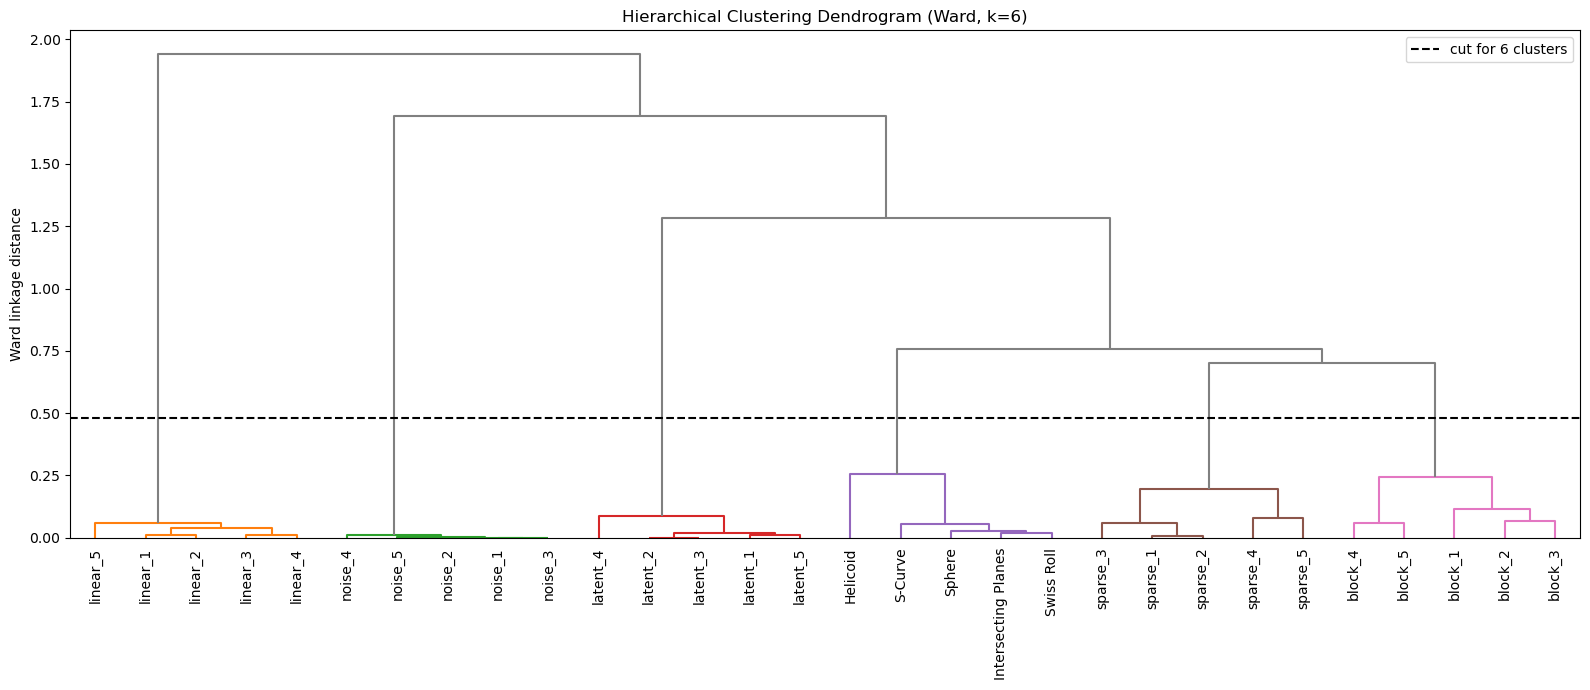

In [5]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.special import expit



# Fulcher-style robust sigmoidal normalisation
def fulcher_sigmoid_normalize(X_df, scale_factor=1.35, eps=1e-12):
    """
    Fulcher-style outlier-robust sigmoidal normalisation.

    For each feature/statistic column j:
        x_ij -> sigmoid((x_ij - median_j) / (scale_factor * IQR_j))

    This uses median and IQR instead of mean and standard deviation,
    making it more robust to extreme statistic values such as large beta.
    """
    X = X_df.copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(axis=0))

    X_values = X.to_numpy(dtype=float)

    med = np.median(X_values, axis=0)
    q75 = np.quantile(X_values, 0.75, axis=0)
    q25 = np.quantile(X_values, 0.25, axis=0)
    iqr = q75 - q25

    # If IQR is zero or extremely small, fall back to standard deviation
    std = np.std(X_values, axis=0)
    scale = scale_factor * iqr
    scale = np.where(scale > eps, scale, std)
    scale = np.where(scale > eps, scale, 1.0)

    X_norm = expit((X_values - med) / scale)

    X_norm_df = pd.DataFrame(
        X_norm,
        index=X.index,
        columns=X.columns
    )

    return X_norm_df



results = pd.concat(all_results_30)

if isinstance(results.index, pd.MultiIndex):
    results = results.copy()
    results.index = results.index.get_level_values(0)

X_df = results.groupby(level=0).mean(numeric_only=True)

if isinstance(X_df.columns, pd.MultiIndex):
    X_df.columns = [
        "__".join([str(x) for x in col if str(x) != ""])
        for col in X_df.columns.to_flat_index()
    ]





# get fulcher normalised matrix

X_fulcher = fulcher_sigmoid_normalize(X_df)


X_scaled = X_fulcher.values
print("Fulcher-normalised matrix shape:", X_fulcher.shape)



# Ward hierarchical clustering

Z = linkage(X_scaled, method="ward")

# cut to 6 classes
clusters = fcluster(Z, t=6, criterion="maxclust")

cluster_df = pd.DataFrame({
    "dataset": X_df.index,
    "cluster": clusters
}).sort_values(["cluster", "dataset"])




# compute height

n = X_df.shape[0]
k = 6

h1 = Z[n - k - 1, 2]

h2 = Z[n - k, 2] if (n - k) < Z.shape[0] else h1 + 1.0

cut_height = (h1 + h2) / 2.0

print(f"Cut height for {k} clusters: {cut_height:.4f}")



# draw dendrogram

plt.figure(figsize=(16, 7))

dendrogram(
    Z,
    labels=X_df.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=cut_height,
    above_threshold_color="gray",
)

plt.axhline(
    y=cut_height,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"cut for {k} clusters"
)

plt.title(f"Hierarchical Clustering Dendrogram (Ward, k={k})")
plt.ylabel("Ward linkage distance")
plt.legend()
plt.tight_layout()


plt.savefig("hierarchical_clustering_fulcher_normalised.pdf", format="pdf", bbox_inches="tight")

plt.show()

Dataset correlation matrix shape: (30, 30)


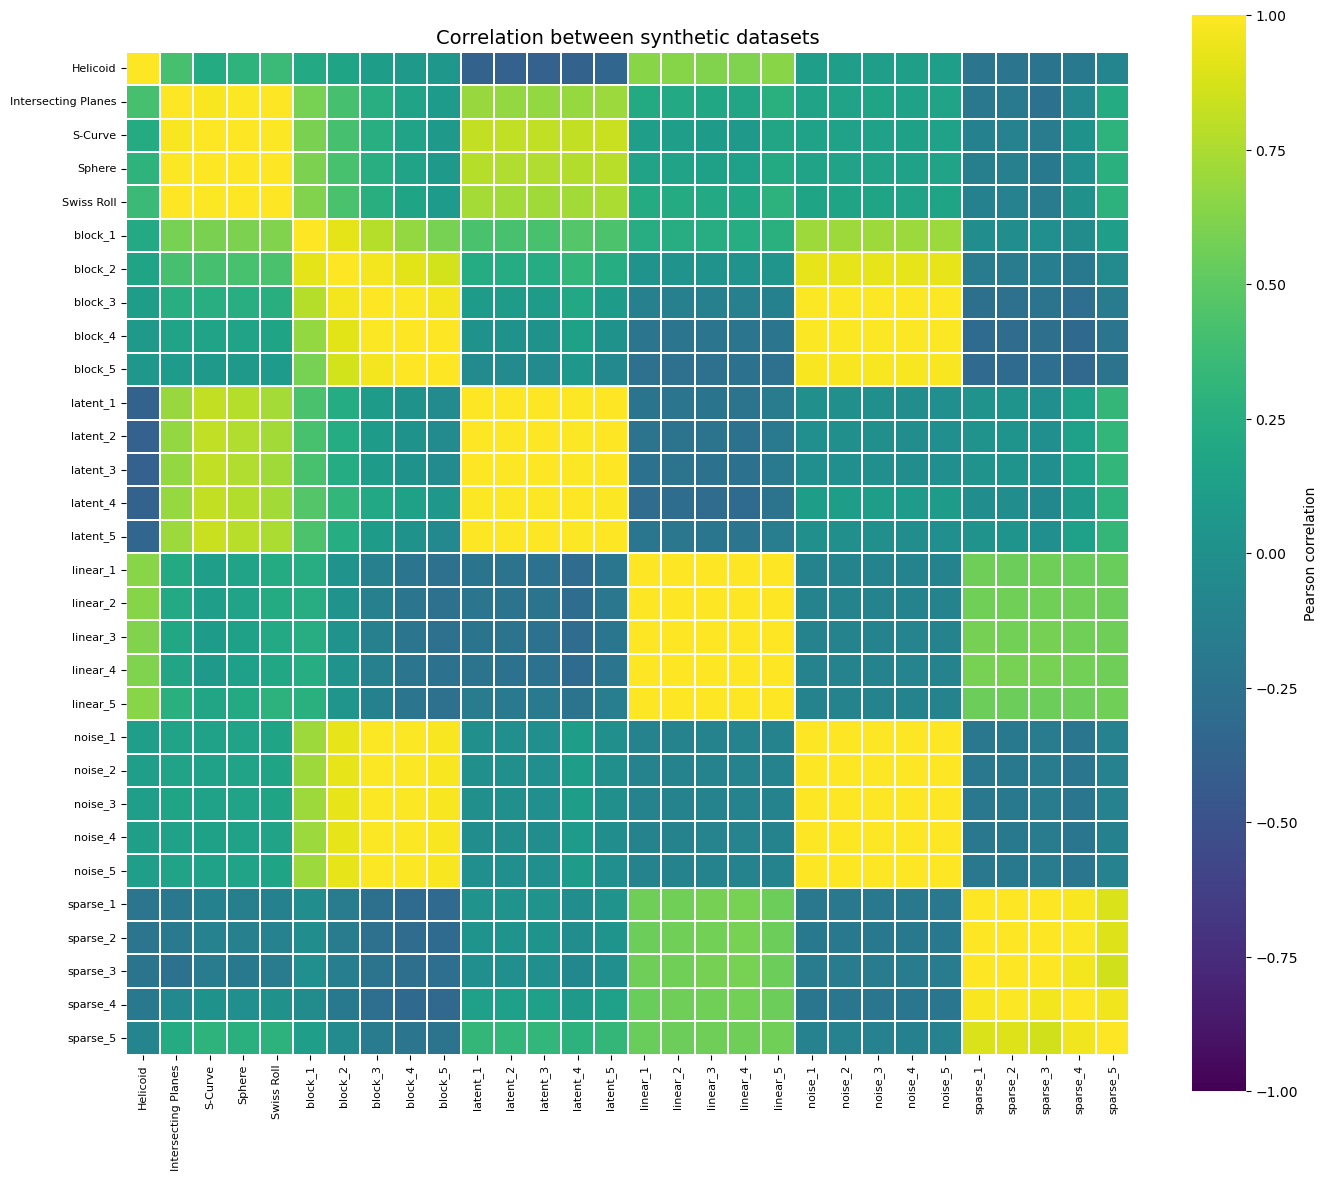

In [6]:
import seaborn as sns

X_heat = X_df.copy()

X_fulcher = fulcher_sigmoid_normalize(X_heat)

X_scaled_df = pd.DataFrame(
    X_fulcher.values,
    index=X_heat.index,
    columns=X_heat.columns
)


# calculate correlations between datasets
dataset_corr = X_scaled_df.T.corr(method="pearson")

print("Dataset correlation matrix shape:", dataset_corr.shape)


# draw heatmap
plt.figure(figsize=(14, 12))

sns.heatmap(
    dataset_corr,
    cmap="viridis",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation between synthetic datasets",
    fontsize=14
)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

plt.savefig(
    "dataset_correlation_heatmap_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

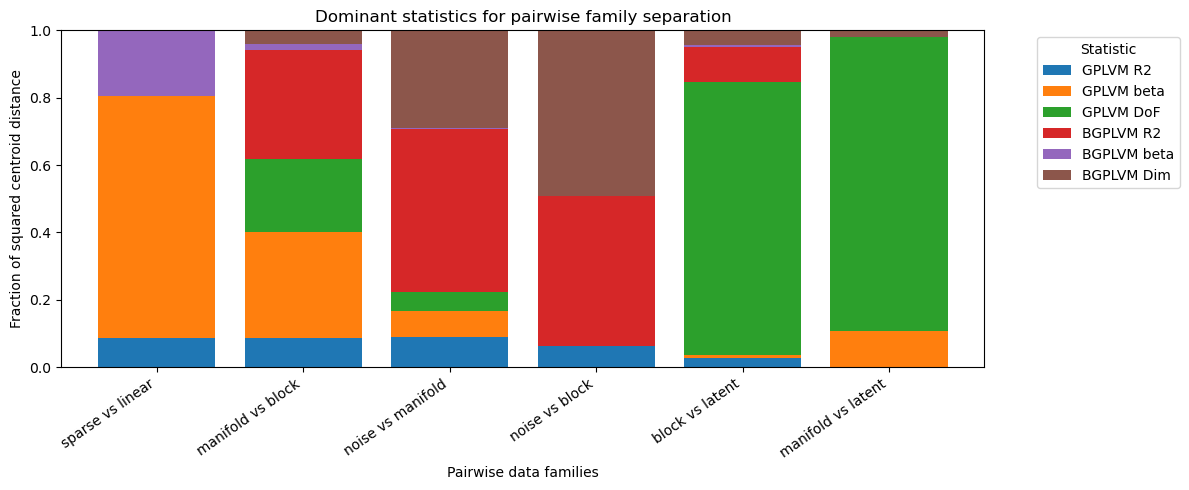

In [7]:
results = results.copy()

if isinstance(results.index, pd.MultiIndex):
    results.index = results.index.get_level_values(0)


X_df = results.groupby(level=0).mean(numeric_only=True)


if isinstance(X_df.columns, pd.MultiIndex):
    X_df.columns = [
        "__".join([str(x) for x in col if str(x) != ""])
        for col in X_df.columns.to_flat_index()
    ]

X_df = X_df.select_dtypes(include=[np.number])

non_constant_cols = X_df.columns[X_df.std(axis=0) > 1e-12]
X_df = X_df[non_constant_cols]


if X_df.shape[1] == 6:
    X_df.columns = [
        "GPLVM R2",
        "GPLVM beta",
        "GPLVM DoF",
        "BGPLVM R2",
        "BGPLVM beta",
        "BGPLVM Dim",
    ]
else:
    print("Warning: X_df does not have exactly 6 columns. Please check columns above.")


X_z = fulcher_sigmoid_normalize(X_df)


def get_family(dataset_name):
    name = str(dataset_name)

    if name in ["Swiss Roll", "S-Curve", "Helicoid", "Sphere", "Intersecting Planes"]:
        return "manifold"
    elif name.startswith("latent"):
        return "latent"
    elif name.startswith("sparse"):
        return "sparse"
    elif name.startswith("linear"):
        return "linear"
    elif name.startswith("block"):
        return "block"
    elif name.startswith("noise"):
        return "noise"
    else:
        return "other"


families = pd.Series(
    [get_family(name) for name in X_z.index],
    index=X_z.index,
    name="family"
)

# compute centroids
centroids = X_z.groupby(families).mean()
family_order = ["manifold", "latent", "sparse", "linear", "block", "noise"]
centroids = centroids.loc[[f for f in family_order if f in centroids.index]]

# compute contributions
def pair_contribution(g1, g2, centroids):
    diff = centroids.loc[g1] - centroids.loc[g2]
    denom = diff.pow(2).sum()

    if denom == 0:
        return diff * np.nan

    contrib = diff.pow(2) / denom
    return contrib


pairs = [
    ("sparse", "linear"),
    ("manifold", "block"),
    ("noise", "manifold"),
    ("noise", "block"),
    ("block", "latent"),
    ("manifold", "latent"),
]


pairs = [(a, b) for a, b in pairs if a in centroids.index and b in centroids.index]

contrib_df = pd.DataFrame({
    f"{a} vs {b}": pair_contribution(a, b, centroids)
    for a, b in pairs
}).T


ax = contrib_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    width=0.8
)

plt.ylabel("Fraction of squared centroid distance")
plt.xlabel("Pairwise data families")
plt.title("Dominant statistics for pairwise family separation")
plt.ylim(0, 1.0)
plt.legend(
    title="Statistic",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("pairwise comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

These are heatmaps and hierarchical clustering dendrogram between statistics rather than between datasets.

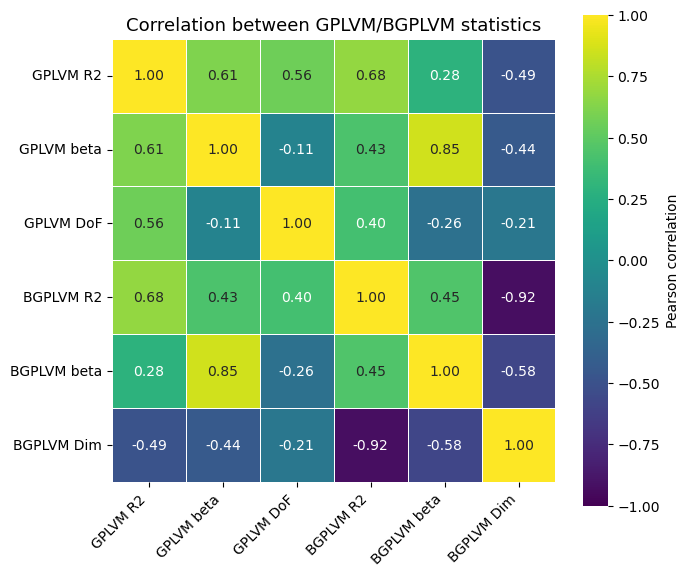

In [8]:
X_fulcher = fulcher_sigmoid_normalize(X_df)


# Correlation between statistics

stat_corr = X_fulcher.corr(method="pearson")



plt.figure(figsize=(7, 6))

sns.heatmap(
    stat_corr,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation between GPLVM/BGPLVM statistics",
    fontsize=13
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "statistics_correlation_heatmap_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

The output of the hierarchical clustering between statistics is relatively unstable. DoF and Dim are sometimes clustered together, but not always. This may because they do not measure the same notion of complexity, as stated in the thesis.

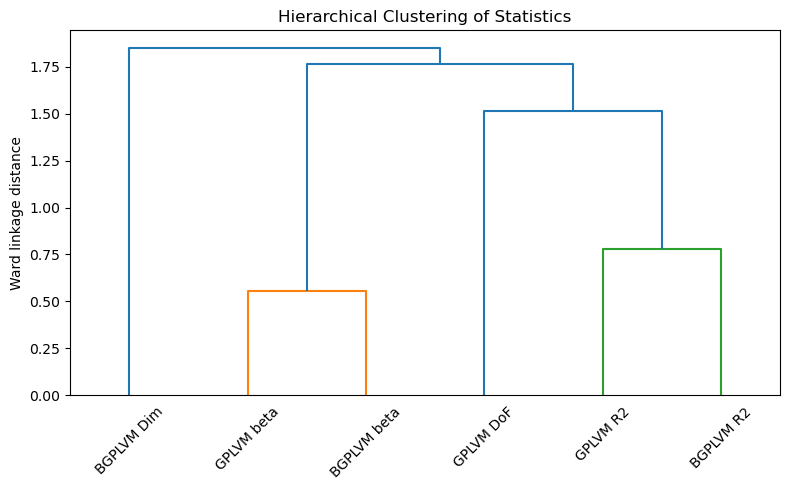

In [14]:
X_fulcher = fulcher_sigmoid_normalize(X_df)

# Transpose: rows = statistics, columns = datasets
D = X_fulcher.T


# Ward clustering between the 6 statistics 
Z_stat = linkage(D.values, method="ward")

# Plot dendrogram
plt.figure(figsize=(8, 5))

dendrogram(
    Z_stat,
    labels=D.index.tolist(),
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=None
)

plt.title("Hierarchical Clustering of Statistics")
plt.ylabel("Ward linkage distance")
plt.tight_layout()

plt.savefig(
    "statistics_hierarchical_clustering_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Now we include real-world datasets into the data matrix:

In [15]:
# SP500 stock price datasets
file_path = '/Users/tongxinran/Desktop/SP500/sp500_stocks.csv'
df = pd.read_csv(file_path)
matrix_df = df.pivot(index='Date', columns='Symbol', values='Adj Close')
matrix_df_clean = matrix_df.dropna(axis=1, how='any')
log_returns_df = np.log(matrix_df_clean).diff().dropna()

all_symbols = log_returns_df.columns.tolist()
total_days = len(log_returns_df)

n_required = 1000
p_required = 100
target_count = 10
current_count = 0

finance_datasets = {}

while current_count < target_count:
    sampled_symbols = np.random.choice(all_symbols, size=n_required, replace=(len(all_symbols) < n_required))
    start_idx = np.random.randint(0, total_days)
    
    if start_idx + p_required <= total_days:
        end_idx = start_idx + p_required
        

        log_returns = log_returns_df.iloc[start_idx:end_idx][sampled_symbols].T.to_numpy()
        
        current_count += 1
        finance_datasets[f'finance{current_count}'] = log_returns
    else:
        continue

locals().update(finance_datasets)

In [16]:
# METABRIC breast cancer datasets
file_path = '/Users/tongxinran/Desktop/Breast Cancer/METABRIC_RNA_Mutation.csv'
df = pd.read_csv(file_path, low_memory=False)

df_numeric = df.select_dtypes(include=['float64', 'int64'])

missing_ratio = df_numeric.isnull().mean()
df_final = df_numeric.loc[:, missing_ratio <= 0.2].copy()

col_median = df_final.median(axis=0, skipna=True)
df_final = df_final.fillna(col_median)

df_final = df_final.fillna(0.0)

n_required = 1000 
p_required = 100   
target_count = 10
breast_cancer_dict = {}

all_columns = df_final.columns.to_list()

for i in range(1, target_count + 1):
    sampled_rows = df_final.sample(n=n_required, replace=False)
    sampled_cols = np.random.choice(all_columns, size=p_required, replace=False)
    final_array = sampled_rows[sampled_cols].to_numpy(dtype=np.float64)

    final_array[~np.isfinite(final_array)] = 0.0

    breast_cancer_dict[f'breast{i}'] = final_array

locals().update(breast_cancer_dict)

In [17]:
# Human activity datasets
file_path = '/Users/tongxinran/Desktop/Human Activity/train.csv'
df = pd.read_csv(file_path, low_memory=False)
df = df.select_dtypes(include=['float64', 'int64'])
human_dict = {}

for i in range(1, target_count + 1):
    sampled_rows = df.sample(n=n_required)
    
    all_columns = sampled_rows.columns.tolist()
    sampled_cols = np.random.choice(all_columns, size=p_required, replace=False)

    final_array = sampled_rows[sampled_cols].to_numpy()
    

    dataset_name = f'human{i}'
    human_dict[dataset_name] = final_array
    

locals().update(human_dict)

In [18]:
def zscore_columns(X: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    return (X - mu) / sd


def run_all_and_store_results(datasets: dict, cfg, do_zscore=False):
    all_results = {}
    names = sorted(datasets.keys())

    for i, name in enumerate(names, 1):
        X = datasets[name]
        if do_zscore:
            X = zscore_columns(X)

        calc = Calculator(X)
        calc.compute(cfg)
        all_results[name] = calc.results  

        print(f"[{i:02d}/{len(names)}] done: {name}")

    return all_results


# combine all real-world datasets together
datasets_empirical = {}
datasets_empirical.update(finance_datasets)        # finance1 to finance10
datasets_empirical.update(breast_cancer_dict)      # breast1 to breast10
datasets_empirical.update(human_dict)              # human1 to human10

# run py-spoc
all_results_empirical = run_all_and_store_results(datasets_empirical, cfg, do_zscore=True)

# py-spoc data matrix
df_all_empirical = pd.concat(all_results_empirical)
print("df_all_empirical shape:", df_all_empirical.shape)

Normalising the dataset using StandardScaler 



Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch



Calculation complete. Time taken: 107.1483s
[01/30] done: breast1
Normalising the dataset using StandardScaler 



Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch



Calculation complete. Time taken: 129.3599s
[02/30] done: breast10
Normalising the dataset using StandardScaler 



...


Calculation complete. Time taken: 132.9092s
[28/30] done: human7
Normalising the dataset using StandardScaler 



Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch



Calculation complete. Time taken: 129.0473s
[29/30] done: human8
Normalising the dataset using StandardScaler 



Processing [None: GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.sch


Calculation complete. Time taken: 131.7756s
[30/30] done: human9
df_all_empirical shape: (30, 6)


In [109]:
df_all_empirical

,Statistic,GPLVM_R2.py.GPLVM_r2.scheme_1,GPLVM_Beta.py.GPLVM_beta.scheme_1,GPLVM_DoF.py.GPLVM_dof.scheme_1,GPyTorch_BayesianGPLVM_R2.py.GPyTorch_BayesianGPLVM_R2.scheme_1,GPyTorch_BayesianGPLVM_Beta.py.GPyTorch_BayesianGPLVM_Beta.scheme_1,GPyTorch_BayesianGPLVM_Dim3.py.GPyTorch_BayesianGPLVM_Dim3.scheme_1
,Reducer,self,self,self,self,self,self
breast1,0,0.401707,4.530905e+00,415.447778,0.484591,7.620319,4.0
breast10,0,0.167980,1.767715e+00,11.175790,0.400702,5.390753,5.0
breast2,0,0.217389,1.935665e+00,29.008308,0.405468,5.008769,5.0
breast3,0,0.379123,1.844542e+00,383.201022,0.432184,6.281789,5.0
breast4,0,0.195272,1.861518e+00,11.238662,0.453758,6.215259,2.0
breast5,0,0.204522,1.852830e+00,11.286075,0.429619,4.434356,4.0
breast6,0,0.357692,1.696879e+00,363.463434,0.388368,5.976919,5.0
breast7,0,0.215091,1.399506e+00,10.813800,0.440263,5.991069,5.0
breast8,0,0.180349,1.834704e+00,11.196851,0.406099,4.437910,4.0


In [138]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list, fcluster


def results_to_matrix(results_obj):
    """
    Convert py-spoc concatenated results into a dataset x statistic matrix.
    Rows = datasets
    Columns = statistics
    """
    df = results_obj.copy()


    if isinstance(df.index, pd.MultiIndex):
        df.index = df.index.get_level_values(0)


    X = df.groupby(level=0).mean(numeric_only=True)


    if isinstance(X.columns, pd.MultiIndex):
        X.columns = [
            "__".join([str(x) for x in col if str(x) != ""])
            for col in X.columns.to_flat_index()
        ]


    X = X.select_dtypes(include=[np.number])

    return X



X_synthetic = results_to_matrix(results)
X_empirical = results_to_matrix(df_all_empirical)


X_synthetic.index = [f"syn_{idx}" for idx in X_synthetic.index]
X_empirical.index = [f"emp_{idx}" for idx in X_empirical.index]

print("Synthetic matrix shape:", X_synthetic.shape)
print("Empirical matrix shape:", X_empirical.shape)


common_cols = X_synthetic.columns.intersection(X_empirical.columns)

X_synthetic = X_synthetic[common_cols]
X_empirical = X_empirical[common_cols]

X_all = pd.concat([X_synthetic, X_empirical], axis=0)


non_constant_cols = X_all.columns[X_all.std(axis=0) > 1e-12]
X_all = X_all[non_constant_cols]


if X_all.shape[1] == 6:
    X_all.columns = [
        "GPLVM R2",
        "GPLVM beta",
        "GPLVM DoF",
        "BGPLVM R2",
        "BGPLVM beta",
        "BGPLVM Dim",
    ]

print("Combined data matrix shape:", X_all.shape)


X_clean = X_all.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.fillna(X_clean.median(axis=0))

Synthetic matrix shape: (30, 6)
Empirical matrix shape: (30, 6)
Combined data matrix shape: (60, 6)


### This is the (60, 6) py-spoc data matrix

In [139]:
X_all

,GPLVM R2,GPLVM beta,GPLVM DoF,BGPLVM R2,BGPLVM beta,BGPLVM Dim
syn_Helicoid,1.006077,1.219452e+02,10.802928,1.010091,235.662725,2.0
syn_Intersecting Planes,1.015113,1.174785e+02,18.264884,1.010392,177.722907,3.0
syn_S-Curve,1.012815,1.174129e+02,20.945148,1.009792,199.342776,3.0
syn_Sphere,1.013525,1.145476e+02,19.526130,1.010449,199.650977,3.0
syn_Swiss Roll,1.014689,1.157342e+02,18.746942,1.009962,251.101452,3.0
syn_block_1,0.575621,3.959511e+00,11.418032,0.749920,6.663947,2.0
syn_block_2,0.569157,3.860220e+00,11.289557,0.750735,6.636018,3.0
syn_block_3,0.577572,3.931008e+00,11.362940,0.749792,6.637968,4.0
syn_block_4,0.578775,3.896682e+00,11.470878,0.746519,6.495257,5.0
syn_block_5,0.531414,3.729664e+00,11.226195,0.743449,6.501143,6.0


In [140]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


X_fulcher = fulcher_sigmoid_normalize(X_clean)

X_scaled_df = pd.DataFrame(
    X_fulcher.values,
    index=X_clean.index,
    columns=X_clean.columns
)

print("Fulcher-normalised matrix shape:", X_scaled_df.shape)


# hierarchical clustering on datasets

Z = linkage(X_scaled_df.values, method="ward")

# 9 clusters

k = 9

clusters = fcluster(
    Z,
    t=k,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "dataset": X_scaled_df.index,
    "cluster": clusters
}).sort_values(["cluster", "dataset"])



def get_true_family(dataset_name):
    """
    Map each dataset name to its true dataset family.
    Assumes names are prefixed by syn_ or emp_.
    """
    name = str(dataset_name)

    # Remove prefix
    if name.startswith("syn_"):
        name0 = name.replace("syn_", "", 1)
    elif name.startswith("emp_"):
        name0 = name.replace("emp_", "", 1)
    else:
        name0 = name

    # Synthetic dataset families
    if name0 in ["Swiss Roll", "S-Curve", "Helicoid", "Sphere", "Intersecting Planes"]:
        return "manifold"
    elif name0.startswith("latent"):
        return "latent"
    elif name0.startswith("sparse"):
        return "sparse"
    elif name0.startswith("linear"):
        return "linear"
    elif name0.startswith("block"):
        return "block"
    elif name0.startswith("noise"):
        return "noise"

    # Empirical dataset families
    elif name0.startswith("finance"):
        return "finance"
    elif name0.startswith("breast"):
        return "breast"
    elif name0.startswith("human"):
        return "human"

    else:
        return "other"


cluster_eval_df = cluster_df.copy()
cluster_eval_df["true_family"] = cluster_eval_df["dataset"].map(get_true_family)





# Compute ARI, NMI

y_true = cluster_eval_df["true_family"].values
y_pred = cluster_eval_df["cluster"].values

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)


print("\nClustering evaluation metrics with Fulcher-style normalisation:")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")


Fulcher-normalised matrix shape: (60, 6)

Clustering evaluation metrics with Fulcher-style normalisation:
Adjusted Rand Index (ARI): 0.8369
Normalized Mutual Information (NMI): 0.9273


Fulcher-normalised matrix shape: (60, 6)


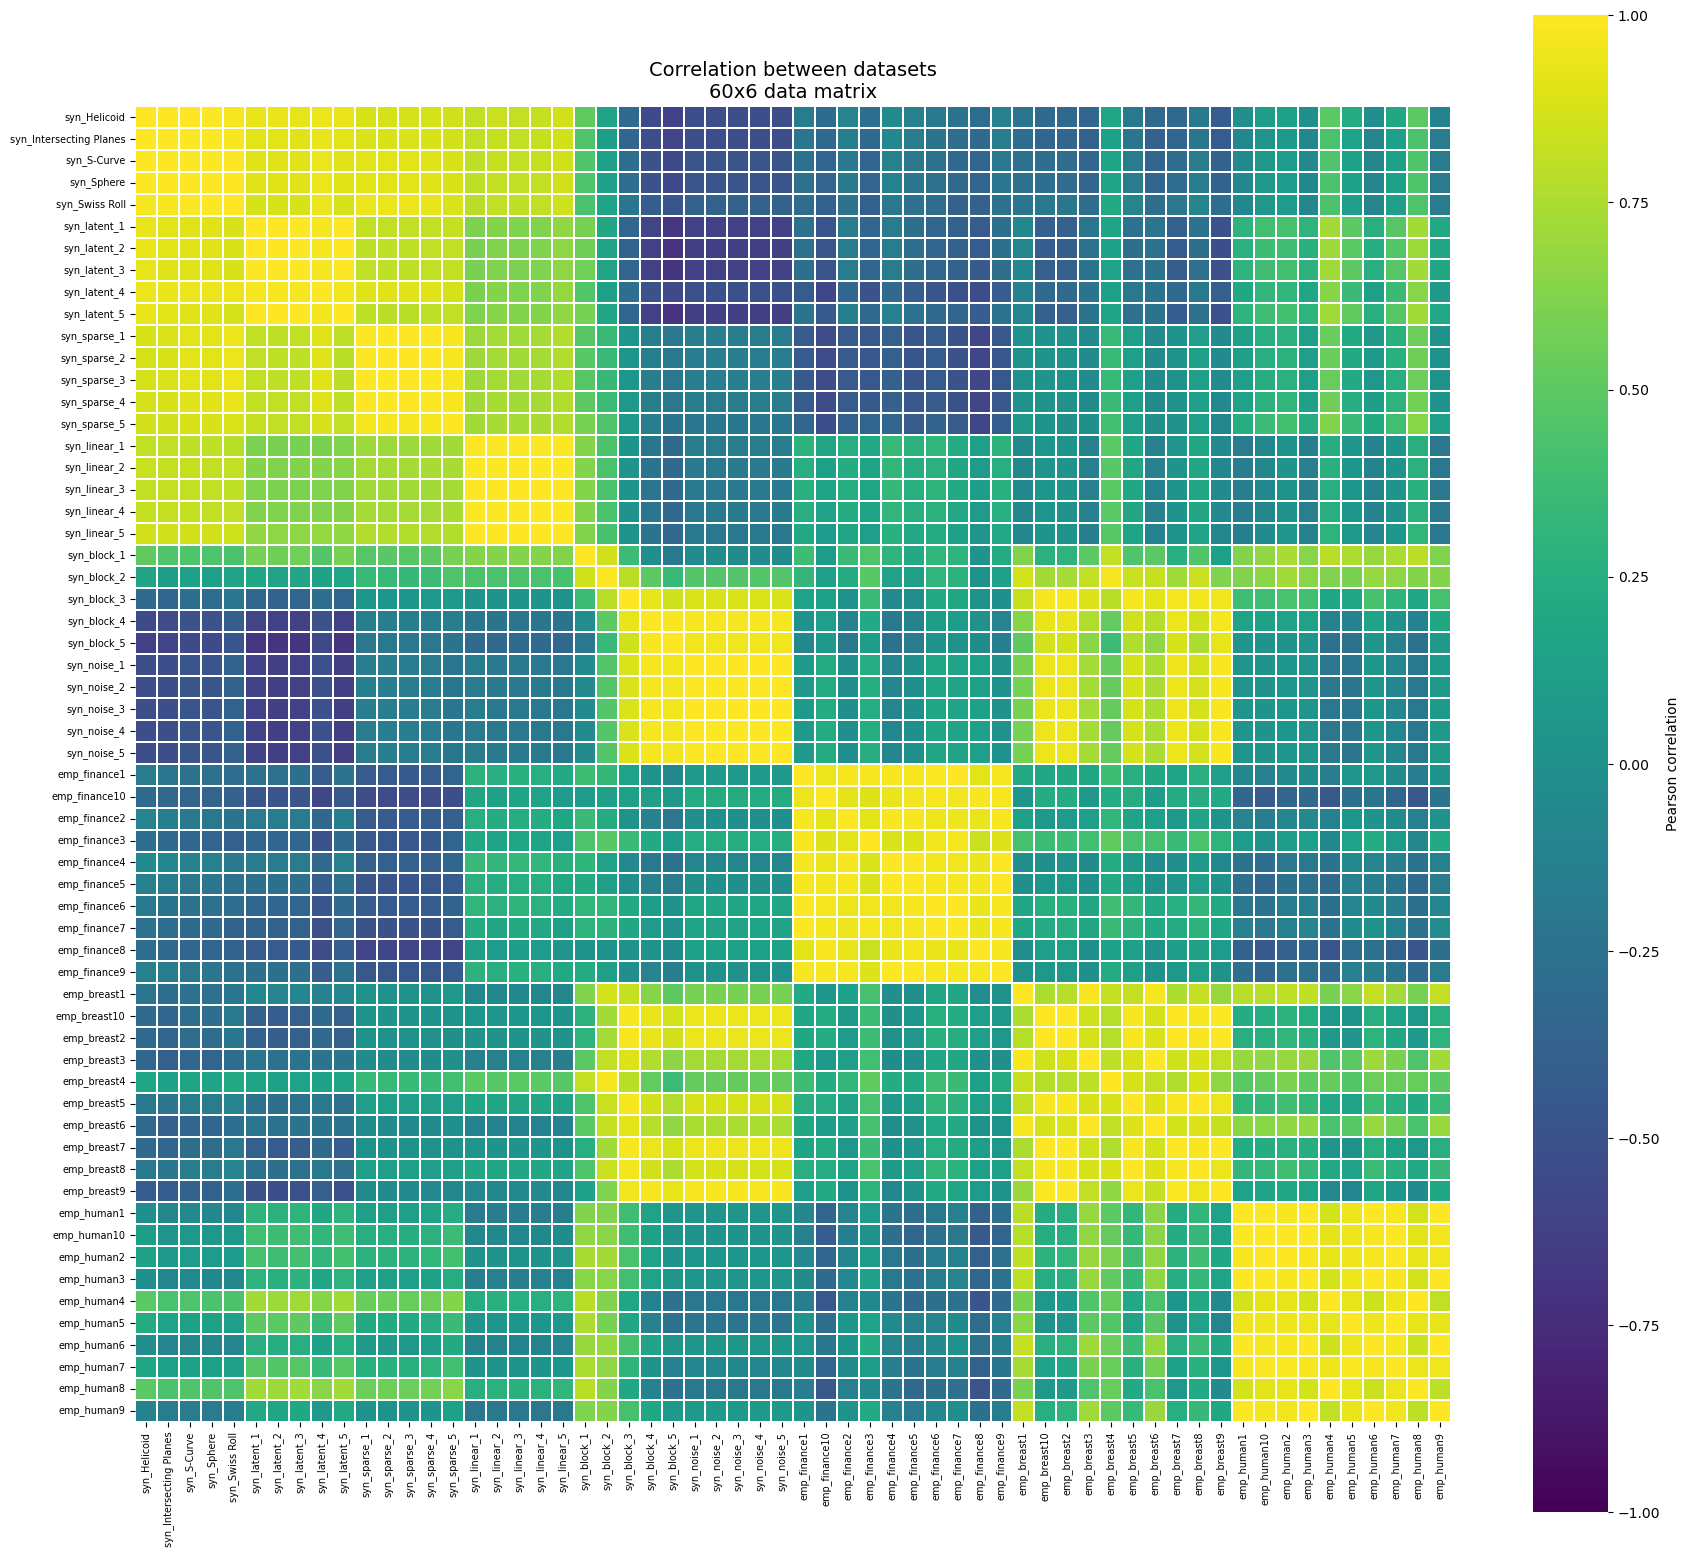

In [142]:
X_fulcher = fulcher_sigmoid_normalize(X_clean)

X_fulcher_df = pd.DataFrame(
    X_fulcher.values,
    index=X_clean.index,
    columns=X_clean.columns
)

print("Fulcher-normalised matrix shape:", X_fulcher_df.shape)


family_series = pd.Series(
    [get_true_family(idx) for idx in X_fulcher_df.index],
    index=X_fulcher_df.index,
    name="family"
)

family_order = [
    "manifold",
    "latent",
    "sparse",
    "linear",
    "block",
    "noise",
    "finance",
    "breast",
    "human",
]

order_df = pd.DataFrame({
    "dataset": X_fulcher_df.index,
    "family": family_series.loc[X_fulcher_df.index].values
})

order_df["family"] = pd.Categorical(
    order_df["family"],
    categories=family_order,
    ordered=True
)

order_df = order_df.sort_values(["family", "dataset"])
ordered_datasets = order_df["dataset"].tolist()



dataset_corr = X_fulcher_df.T.corr(method="pearson")
dataset_corr_ordered = dataset_corr.loc[ordered_datasets, ordered_datasets]


plt.figure(figsize=(18, 16))

sns.heatmap(
    dataset_corr_ordered,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.12,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation between datasets\n"
    "60x6 data matrix",
    fontsize=14
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

plt.savefig(
    "dataset_correlation_heatmap_60x6_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Now we do a final experiment, we include other existing py-spoc statistics into the data matrix:

In [120]:
# combine synthetic datasets and real-world datasets
datasets_combined = {}

for name, X in all_datasets_30.items():
    datasets_combined[f"syn_{name}"] = X

for name, X in datasets_empirical.items():
    datasets_combined[f"emp_{name}"] = X

print("Total number of datasets:", len(datasets_combined))

for name, X in datasets_combined.items():
    print(name, X.shape)



# put into py-spoc framework

all_results_combined = {}

for i, (name, X) in enumerate(datasets_combined.items(), start=1):

    print(f"\n[{i:02d}/{len(datasets_combined)}] Computing: {name}, shape={X.shape}")

    cfg = Config.from_yaml_file("mega_yaml", "mega_yaml.yml")

    calc = Calculator(X)
    calc.compute(cfg)

    results = calc.results

    all_results_combined[name] = results

    print(f"Done: {name}")




results_combined = pd.concat(all_results_combined)

print("Combined results shape:", results_combined.shape)
results_combined

Total number of datasets: 60
syn_Swiss Roll (1000, 100)
syn_S-Curve (1000, 100)
syn_Helicoid (1000, 100)
syn_Sphere (1000, 100)
syn_Intersecting Planes (1000, 100)
syn_latent_1 (1000, 100)
syn_latent_2 (1000, 100)
syn_latent_3 (1000, 100)
syn_latent_4 (1000, 100)
syn_latent_5 (1000, 100)
syn_sparse_1 (1000, 100)
syn_sparse_2 (1000, 100)
syn_sparse_3 (1000, 100)
syn_sparse_4 (1000, 100)
syn_sparse_5 (1000, 100)
syn_linear_1 (1000, 100)
syn_linear_2 (1000, 100)
syn_linear_3 (1000, 100)
syn_linear_4 (1000, 100)
syn_linear_5 (1000, 100)
syn_block_1 (1000, 100)
syn_block_2 (1000, 100)
syn_block_3 (1000, 100)
syn_block_4 (1000, 100)
syn_block_5 (1000, 100)
syn_noise_1 (1000, 100)
syn_noise_2 (1000, 100)
syn_noise_3 (1000, 100)
syn_noise_4 (1000, 100)
syn_noise_5 (1000, 100)
emp_finance1 (1000, 100)
emp_finance2 (1000, 100)
emp_finance3 (1000, 100)
emp_finance4 (1000, 100)
emp_finance5 (1000, 100)
emp_finance6 (1000, 100)
emp_finance7 (1000, 100)
emp_finance8 (1000, 100)
emp_finance9 (1000, 1

Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|█| 1/1 [00
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum











Calculation complete. Time taken: 0.7047s
Done: syn_Swiss Roll

[02/60] Computing: syn_S-Curve, shape=(1000, 100)
Registering YAML configuration file: mega_yaml.yml.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'empirical' added successfully.
  ✔ Module /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py already loaded.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'canberra_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_skew_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_skew_meance

Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|█| 1/1 [00
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum











Calculation complete. Time taken: 0.4576s
Done: syn_S-Curve

[03/60] Computing: syn_Helicoid, shape=(1000, 100)
Registering YAML configuration file: mega_yaml.yml.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'empirical' added successfully.
  ✔ Module /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py already loaded.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'canberra_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_skew_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_skew_meancent

...

Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|█| 1/1 [00
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum











Calculation complete. Time taken: 1.2844s
Done: emp_human9

[60/60] Computing: emp_human10, shape=(1000, 100)
Registering YAML configuration file: mega_yaml.yml.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic already loaded.
    ✔ Statistic Covariance scheme 'empirical' added successfully.
  ✔ Module /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py already loaded.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'canberra_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_skew_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_skew_meancentro

Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|█| 1/1 [00
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum
Processing [None: /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/sum











Calculation complete. Time taken: 0.4595s
Done: emp_human10
Combined results shape: (60, 22)


Statistic                                                                                                           pyspoc.statistics.basic.Covariance.empirical  \
Reducer                   /Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.MaxCovPerFeature.max_min_median_1   
syn_Swiss Roll          0                                 0.990472+0.000000j                                                                                       
syn_S-Curve             0                                 0.990858+0.000000j                                                                                       
syn_Helicoid            0                                 0.990869+0.000000j                                                                                       
syn_Sphere              0                                 0.990561+0.000000j                                                                                       
syn_Intersecting Planes 0                                 0.989970+0.000000j                                                                                       
syn_latent_1            0                                 0.984721+0.000000j                                                                                       
syn_latent_2            0                                 0.983628+0.000000j                                                                                       
syn_latent_3            0                                 0.984910+0.000000j                                                                                       
syn_latent_4            0                                 0.981904+0.000000j                                                                                       
syn_latent_5            0                                 0.984412+0.000000j                                                                                       
syn_sparse_1            0                                 0.999970+0.000000j                                                                                       
syn_sparse_2            0                                 0.999977+0.000000j                                                                                       
syn_sparse_3            0                                 0.999975+0.000000j                                                                                       
syn_sparse_4            0                                 0.999980+0.000000j                                                                                       
syn_sparse_5            0                                 0.999968+0.000000j                                                                                       
syn_linear_1            0                                 0.999985+0.000000j                                                                                       
syn_linear_2            0                                 0.999989+0.000000j                                                                                       
syn_linear_3            0                                 0.999989+0.000000j                                                                                       
syn_linear_4            0                                 0.999989+0.000000j                                                                                       
syn_linear_5            0                                 0.999980+0.000000j                                                                                       
syn_block_1             0                                 0.759759+0.000000j                                                                                       
syn_block_2             0                                 0.754139+0.000000j                                                                                       
syn_block_3             0                                 0.7483

In [144]:
def clean_feature_matrix(df, prefix=None):
    """
    Convert a dataframe into dataset x feature matrix.

    If index is MultiIndex, use the first level as dataset name and average.
    If columns are MultiIndex, flatten them.
    Keep numeric columns only.
    """
    X = df.copy()

    if isinstance(X.index, pd.MultiIndex):
        X.index = X.index.get_level_values(0)
        X = X.groupby(level=0).mean(numeric_only=True)

    if isinstance(X.columns, pd.MultiIndex):
        X.columns = [
            "__".join([str(x) for x in col if str(x) != ""])
            for col in X.columns.to_flat_index()
        ]

    X = X.select_dtypes(include=[np.number])

    if prefix is not None:
        X.columns = [f"{prefix}_{col}" for col in X.columns]

    return X



X_22 = clean_feature_matrix(results_combined, prefix="extra")
X_6 = clean_feature_matrix(X_all, prefix="sixstat")

print("X_22 shape:", X_22.shape)
print("X_6 shape:", X_6.shape)



common_index = X_22.index.intersection(X_6.index)

X_22 = X_22.loc[common_index]
X_6 = X_6.loc[common_index]

X_28 = pd.concat([X_22, X_6], axis=1)


print("Final matrix used for heatmap/clustering:", X_28.shape)



X_clean = X_28.copy()
X_array = X_clean.to_numpy()

# if complex dtype exist but with 0.j，taking the real part
if np.iscomplexobj(X_array):
    max_imag = np.nanmax(np.abs(np.imag(X_array)))
    print(f"Maximum absolute imaginary part: {max_imag:.3e}")

    if max_imag < 1e-10:
        X_clean = pd.DataFrame(
            np.real(X_array),
            index=X_clean.index,
            columns=X_clean.columns
        )
    else:
        complex_cols = [
            col for col in X_clean.columns
            if np.iscomplexobj(X_clean[col].to_numpy())
        ]
        raise ValueError(
            "Some statistics contain non-negligible complex values. "
            f"Please inspect these columns: {complex_cols}"
        )

X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.fillna(X_clean.median(axis=0))
X_clean = X_clean.astype(float)

X_22 shape: (60, 22)
X_6 shape: (60, 6)
Final matrix used for heatmap/clustering: (60, 28)
Maximum absolute imaginary part: 0.000e+00


### This is the (60, 28) py-spoc data matrix

In [145]:
X_clean

,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.MaxCovPerFeature.max_min_median_1,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.MaxCovPerFeature.max_min_median_2,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.MaxCovPerFeature.max_min_median_3,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.EigenAMGMRatio.eigen_amgm,extra_pyspoc.statistics.basic.Covariance.empirical__/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.EigenEntropy.eigen_entropy,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.cosine_distrib_meancentroid__self_1,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.cosine_distrib_meancentroid__self_2,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.cosine_distrib_meancentroid__self_3,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.euclidean_distrib_meancentroid__self_1,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.euclidean_distrib_meancentroid__self_2,...,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionBasicSummarize.euclidean_kurt_meancentroid__self,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.corr_peaks_meancentroid__self,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.euclidean_peaks_meancentroid__self,extra_/Users/tongxinran/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.canberra_peaks_meancentroid__self,sixstat_GPLVM R2,sixstat_GPLVM beta,sixstat_GPLVM DoF,sixstat_BGPLVM R2,sixstat_BGPLVM beta,sixstat_BGPLVM Dim
emp_breast1,0.831907,0.084745,0.353495,1.560281,4.093598,0.095971,1.000514,0.121726,2.164613,9.762912,...,4.580052,4.0,3.0,3.0,0.401707,4.530905e+00,415.447778,0.484591,7.620319,4.0
emp_breast10,0.671409,0.083949,0.335466,1.459585,4.162959,0.109979,1.000312,0.148964,2.157145,9.764565,...,4.763123,1.0,4.0,1.0,0.167980,1.767715e+00,11.175790,0.400702,5.390753,5.0
emp_breast2,0.838372,0.094546,0.391845,1.495755,4.141407,0.098648,0.998848,0.140548,2.002463,9.797456,...,1.936533,1.0,2.0,5.0,0.217389,1.935665e+00,29.008308,0.405468,5.008769,5.0
emp_breast3,0.665220,0.081751,0.360543,1.497640,4.130045,0.112496,0.995977,0.148791,2.010489,9.795812,...,4.042596,1.0,2.0,6.0,0.379123,1.844542e+00,383.201022,0.432184,6.281789,5.0
emp_breast4,0.719103,0.074721,0.395903,1.590069,4.045262,0.111976,0.996862,0.161395,2.081856,9.780893,...,3.291066,1.0,3.0,4.0,0.195272,1.861518e+00,11.238662,0.453758,6.215259,2.0
emp_breast5,0.595855,0.093819,0.368076,1.519396,4.119224,0.102097,1.001685,0.146406,2.147558,9.766678,...,3.271900,1.0,2.0,3.0,0.204522,1.852830e+00,11.286075,0.429619,4.434356,4.0
emp_breast6,0.647401,0.081619,0.334492,1.454539,4.180435,0.088700,1.001645,0.117443,1.902783,9.817302,...,2.704317,1.0,1.0,3.0,0.357692,1.696879e+00,363.463434,0.388368,5.976919,5.0
emp_breast7,0.692811,0.079500,0.378490,1.554337,4.095212,0.097532,1.002535,0.131170,1.911893,9.815532,...,2.327781

Fulcher-normalised matrix shape: (60, 28)


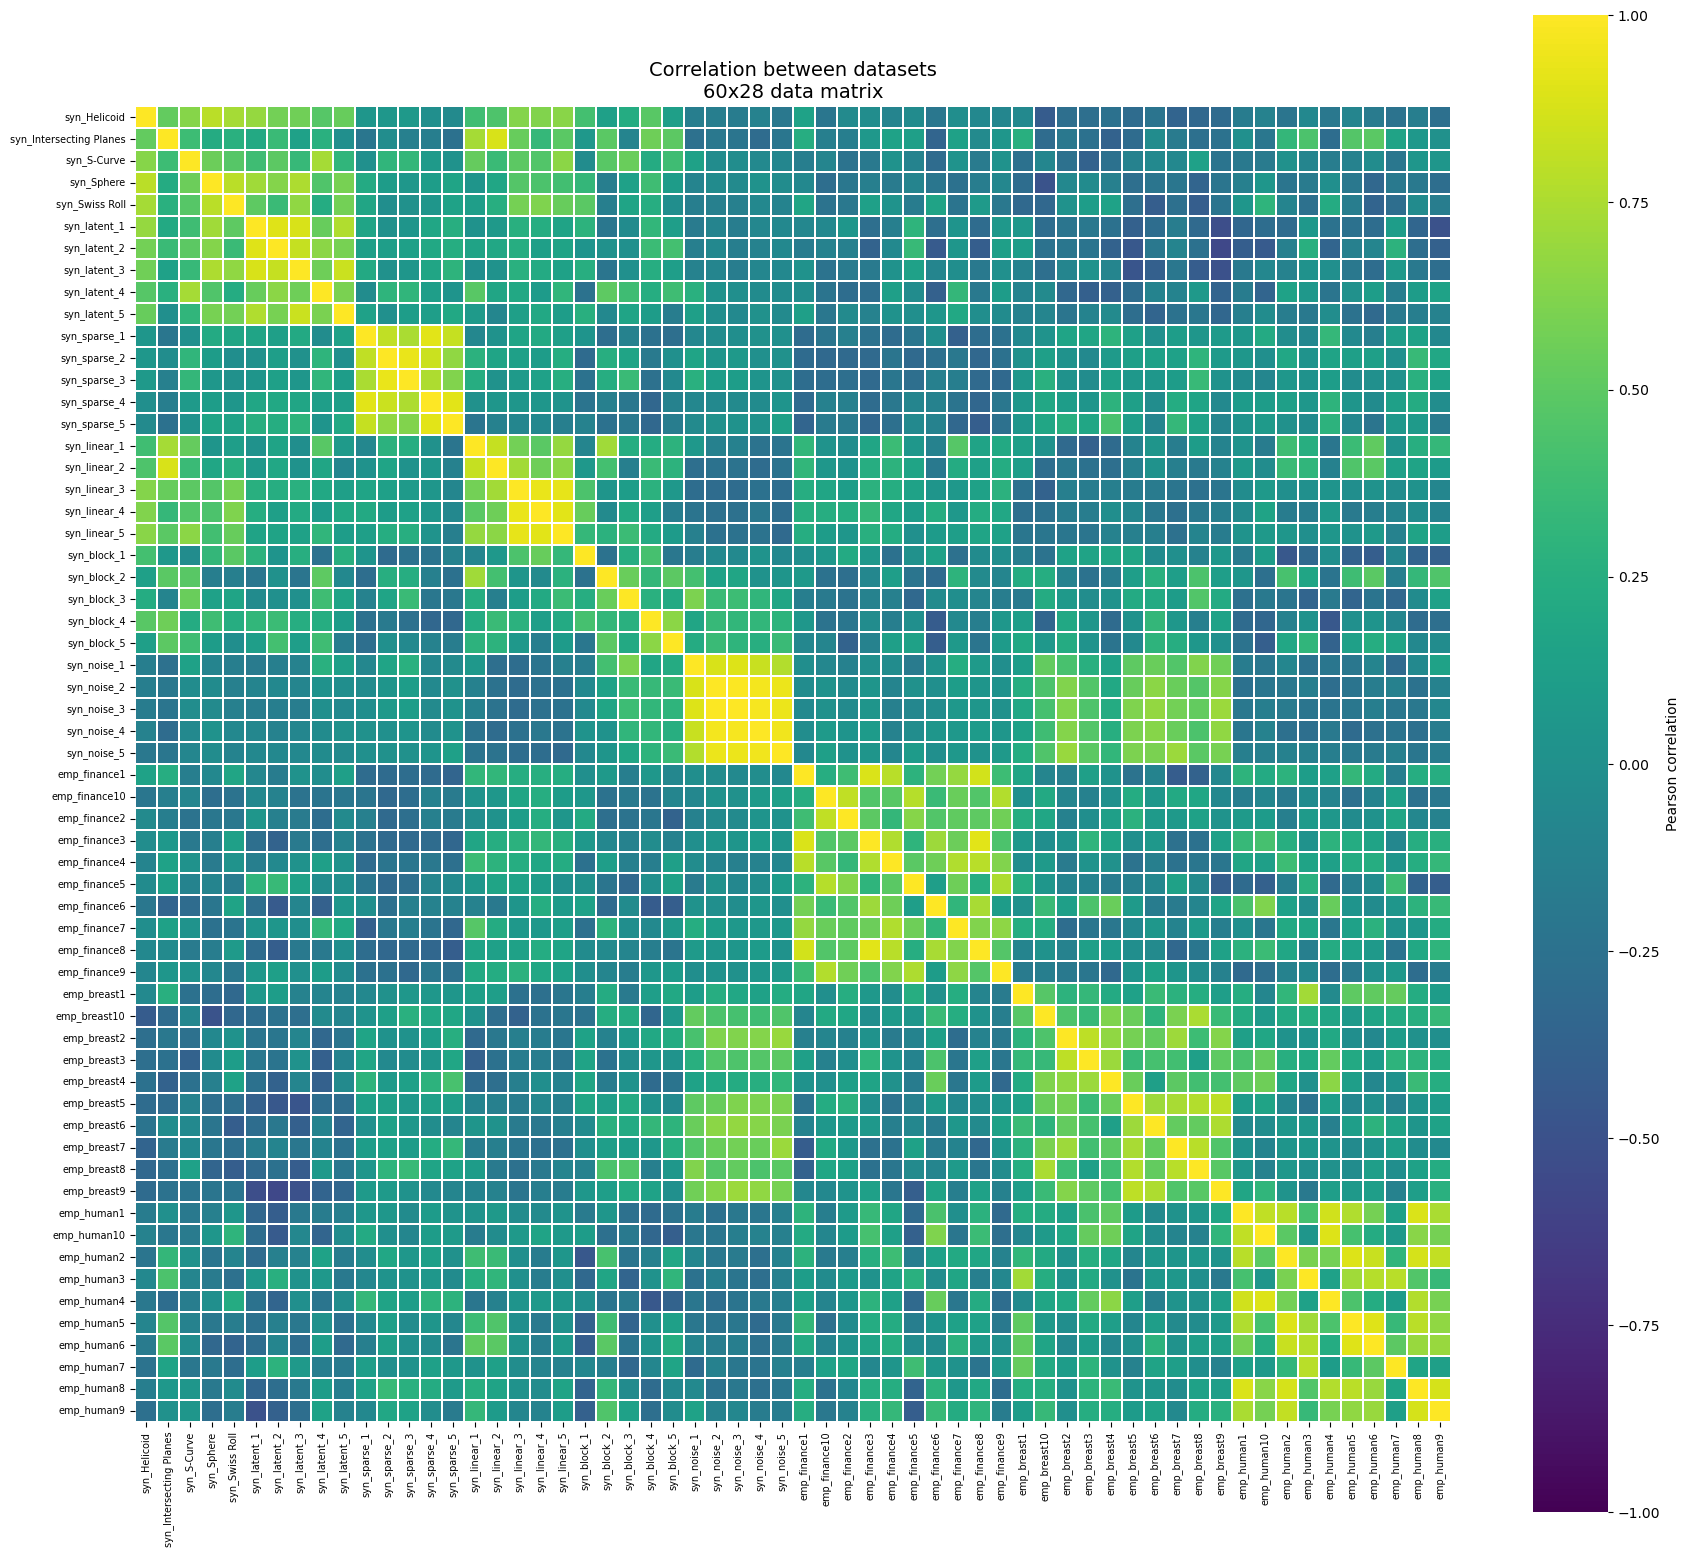

In [146]:
X_fulcher_df = fulcher_sigmoid_normalize(X_clean)

print("Fulcher-normalised matrix shape:", X_fulcher_df.shape)



dataset_corr = X_fulcher_df.T.corr(method="pearson")




family_order = [
    "manifold",
    "latent",
    "sparse",
    "linear",
    "block",
    "noise",
    "finance",
    "breast",
    "human",
]

order_df = pd.DataFrame({
    "dataset": X_fulcher_df.index,
    "family": family_series.loc[X_fulcher_df.index].values
})

order_df["family"] = pd.Categorical(
    order_df["family"],
    categories=family_order,
    ordered=True
)

order_df = order_df.sort_values(["family", "dataset"])
ordered_datasets = order_df["dataset"].tolist()

dataset_corr_grouped = dataset_corr.loc[ordered_datasets, ordered_datasets]


plt.figure(figsize=(18, 16))

ax = sns.heatmap(
    dataset_corr_grouped,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.10,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"}
)

plt.title(
    "Correlation between datasets\n"
    "60x28 data matrix",
    fontsize=14
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

plt.savefig(
    "dataset_correlation_heatmap_60x28_fulcher.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [148]:
Z = linkage(X_fulcher_df.values, method="ward")

k = 9

clusters = fcluster(
    Z,
    t=k,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "dataset": X_fulcher_df.index.astype(str),
    "cluster": clusters
}).sort_values(["cluster", "dataset"])


def get_true_family_robust(dataset_name):
    name = str(dataset_name)

    # remove common prefixes
    if name.startswith("syn_"):
        name0 = name.replace("syn_", "", 1)
    elif name.startswith("emp_"):
        name0 = name.replace("emp_", "", 1)
    else:
        name0 = name

    # lower-case version for robust matching
    low = name0.lower().strip()

    # synthetic manifold datasets
    manifold_names = {
        "swiss roll",
        "s-curve",
        "helicoid",
        "sphere",
        "intersecting planes"
    }

    if low in manifold_names:
        return "manifold"

    # synthetic families
    if low.startswith("latent"):
        return "latent"
    if low.startswith("sparse"):
        return "sparse"
    if low.startswith("linear"):
        return "linear"
    if low.startswith("block"):
        return "block"
    if low.startswith("noise"):
        return "noise"

    # empirical families
    if low.startswith("finance"):
        return "finance"
    if low.startswith("breast"):
        return "breast"
    if low.startswith("human"):
        return "human"

    return "other"


cluster_df["true_family"] = cluster_df["dataset"].map(get_true_family_robust)


unmatched = cluster_df.loc[cluster_df["true_family"] == "other", "dataset"].tolist()
if len(unmatched) > 0:
    print("\nUnmatched dataset names:")
    print(unmatched[:30])


if cluster_df["true_family"].nunique() <= 1:
    raise ValueError(
        "All datasets were mapped to the same true_family. "
        "Please inspect X_fulcher_df.index and update get_true_family_robust()."
    )




# compute ARI, NMI

y_true = cluster_df["true_family"].values
y_pred = cluster_df["cluster"].values

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)

print("\nClustering evaluation metrics:")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")



Clustering evaluation metrics:
Adjusted Rand Index (ARI): 0.6627
Normalized Mutual Information (NMI): 0.8235
